In [ ]:
import tellurium as te
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import platform
import roadrunner
import math
import multiprocessing as mp
from multiprocessing import Pool, cpu_count, Manager
from functools import partial
import psutil
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings
from scipy.signal import find_peaks, hilbert, savgol_filter
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')

# Silence RoadRunner log messages completely
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

print("🧪 ChicoOscillation: Simplified Yeast Dynamics Analysis")
print("📊 Focus: Short-term dynamics with coarse-grained encoding")
print("="*60)

🧪 ChicoOscillation: Simplified Yeast Dynamics Analysis
📊 Focus: Short-term dynamics with coarse-grained encoding


In [3]:
# === CPU OPTIMIZATION DETECTION ===
def detect_cpu_config():
    """Detect optimal CPU configuration for Radeon/AMD processors"""
    cpu_count_total = cpu_count()
    cpu_info = platform.processor()
    
    # Check if this is an AMD/Radeon CPU
    is_amd = any(keyword in cpu_info.lower() for keyword in ['amd', 'radeon', 'ryzen', 'epyc', 'athlon'])
    
    if is_amd:
        # AMD CPUs often benefit from using physical cores only
        try:
            physical_cores = psutil.cpu_count(logical=False)
            logical_cores = psutil.cpu_count(logical=True)
            
            # For AMD, often best to use 75-85% of physical cores for compute-heavy tasks
            optimal_workers = max(1, int(physical_cores * 0.8)) if physical_cores else max(1, int(cpu_count_total * 0.7))
            
            print(f"🔧 AMD/Radeon CPU detected: {cpu_info}")
            print(f"   Physical cores: {physical_cores}, Logical cores: {logical_cores}")
            print(f"   Optimal workers for simulation: {optimal_workers}")
            
            return optimal_workers, True
        except:
            # Fallback if psutil fails
            optimal_workers = max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD CPU detected (fallback): using {optimal_workers} workers")
            return optimal_workers, True
    else:
        # Non-AMD CPU: use standard approach
        optimal_workers = max(1, cpu_count_total - 1)
        print(f"🔧 Non-AMD CPU: using {optimal_workers} workers")
        return optimal_workers, False

OPTIMAL_WORKERS, IS_AMD_CPU = detect_cpu_config()

# Cross-platform path detection
def get_model_path():
    """Get the correct path to the SBML model file based on OS and available paths."""
    # Define possible paths
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"
    Beecroft_path = "/home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"   
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml"
    
    # Check which path exists
    if os.path.exists(linux_path):
        print("linux_path")
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    elif os.path.exists(Beecroft_path):
        print("Beecroft_path")
        return Beecroft_path
    else:
        # Fallback: try to find it relative to current directory
        possible_relative_paths = [
            "chen_model.xml",
            "Chen/chen_model.xml",
            "../Chen/chen_model.xml"
        ]
        for rel_path in possible_relative_paths:
            if os.path.exists(rel_path):
                return os.path.abspath(rel_path)
        
        # If nothing found, raise an error with helpful message
        raise FileNotFoundError(
            f"Could not find chen_model.xml in any of the expected locations:\n"
            f"  Linux: {linux_path}\n"
            f"  Mac: {mac_path}\n"
            f"Current working directory: {os.getcwd()}\n"
            f"Platform: {platform.system()}"
        )

# Load Chen 2004 budding yeast cell cycle model
model_path = get_model_path()
print(f"Loading model from: {model_path}")
rr = te.loadSBMLModel(model_path)

🔧 Non-AMD CPU: using 7 workers
Loading model from: /Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml


In [4]:
# === CHICO OSCILLATION CONFIGURATION ===
# Modified parameters for short-term dynamics analysis

# Parameter sampling configuration (same as CPUheavy)
multipliers = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]  # Discrete multipliers for parameter perturbation

# === MODIFIED SIMULATION SETTINGS ===
T = 500                           # Default simulation time (minutes) - MUCH shorter than CPUheavy!
CoarseStart = 0                  # Start time for coarse-graining window
SIMULATION_TIME = T                 # Total simulation time
SIMULATION_POINTS = 501             # Fewer points needed for shorter simulation
COARSE_BINS = 50                    # Number of bins for coarse-graining (same as CPUheavy)

# Simulation thresholds
DIVERGENCE_THRESHOLD = 250          # Reject divergent solutions
MAX_RETRY_ATTEMPTS = 20             # Maximum attempts to find valid solution in tests
SAMPLING_SIZE = 10**5               # Number of samples to analyze
PROGRESS_INTERVAL = 0.01            # Progress reporting frequency

# Phenotype tracking
N_TRACK_PHENOTYPES = 10             # Number of top/bottom phenotypes to track

# Performance optimization settings (from CPUheavy)
USE_MODEL_REUSE = True              # Reuse single model instance
BATCH_SIZE = 1000                   # Process in batches
ENABLE_FAST_REJECT = True           # Quick rejection of divergent solutions
REDUCED_PRECISION = True            # Use reduced simulation precision for speed

# === CPU PARALLELIZATION SETTINGS ===
USE_MULTIPROCESSING = True          # Enable multiprocessing
NUM_WORKERS = OPTIMAL_WORKERS       # Number of parallel workers
CHUNK_SIZE = max(100, SAMPLING_SIZE // (NUM_WORKERS * 10))  # Dynamic chunk size
USE_PROCESS_POOL = True             # Use ProcessPoolExecutor
ENABLE_MEMORY_OPTIMIZATION = True   # Enable memory optimization

# AMD/Radeon specific optimizations
if IS_AMD_CPU:
    CHUNK_SIZE = max(50, CHUNK_SIZE // 2)
    os.environ['OMP_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['MKL_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['NUMEXPR_NUM_THREADS'] = str(NUM_WORKERS)

print("✓ ChicoOscillation Configuration:")
print(f"   - Multipliers: {multipliers}")
print(f"   - Simulation time: {SIMULATION_TIME} min (SHORT-TERM FOCUS)")
print(f"   - Simulation points: {SIMULATION_POINTS}")
print(f"   - Coarse bins: {COARSE_BINS}")
print(f"   - Divergence threshold: {DIVERGENCE_THRESHOLD}")
print(f"   - Sampling size: {SAMPLING_SIZE:,}")
print(f"   - 🚀 CPU Parallelization: {USE_MULTIPROCESSING} ({NUM_WORKERS} workers)")
print(f"   - 🔧 CPU Type: {'AMD/Radeon optimized' if IS_AMD_CPU else 'Standard'}")
print(f"   - 📦 Chunk size: {CHUNK_SIZE} samples per batch")
print(f"\n🎯 KEY DIFFERENCE: No oscillation detection, just direct coarse-graining!")

✓ ChicoOscillation Configuration:
   - Multipliers: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
   - Simulation time: 500 min (SHORT-TERM FOCUS)
   - Simulation points: 501
   - Coarse bins: 50
   - Divergence threshold: 250
   - Sampling size: 100,000
   - 🚀 CPU Parallelization: True (7 workers)
   - 🔧 CPU Type: Standard
   - 📦 Chunk size: 1428 samples per batch

🎯 KEY DIFFERENCE: No oscillation detection, just direct coarse-graining!


In [5]:
# === CORE FUNCTIONS (adapted from CPUheavy) ===

def get_kinetic_parameters(rr):
    """Get list of kinetic parameters, excluding regulatory switches/flags."""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        # Exclude non-kinetic parameters (switches, flags, totals)
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

# Cache kinetic parameters globally
_kinetic_params_cache = None
_excluded_params_cache = None

def get_kinetic_parameters_cached(rr):
    """Cached version of get_kinetic_parameters for performance"""
    global _kinetic_params_cache, _excluded_params_cache
    if _kinetic_params_cache is None:
        _kinetic_params_cache, _excluded_params_cache = get_kinetic_parameters(rr)
    return _kinetic_params_cache, _excluded_params_cache

def reset_model_to_defaults(rr, default_values):
    """Quickly reset model to default parameter values"""
    for pid, default_val in default_values.items():
        try:
            rr.setValue(pid, default_val)
        except RuntimeError:
            continue

def sample_parameters_fast(rr, kinetic_params, default_values, wildtype=False):
    """Fast parameter sampling using cached parameter lists"""
    
    # Reset to defaults efficiently
    reset_model_to_defaults(rr, default_values)
    rr.resetAll()
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    # Sample only kinetic parameters using cached list
    for pid in kinetic_params:
        try:
            current = default_values[pid]  # Use cached default
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except (RuntimeError, KeyError):
            continue
    
    return sampled, sampled_values

def sample_parameters(rr, wildtype=False):
    """Standard parameter sampling (for compatibility)"""
    rr.resetAll()
    kinetic_params, excluded_params = get_kinetic_parameters(rr)
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    for pid in kinetic_params:
        try:
            current = rr.getValue(pid)
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except RuntimeError:
            continue
    
    return sampled, sampled_values

def check_divergence_fast(signal, threshold):
    """Fast divergence check on CLB2 signal"""
    if threshold is None:
        return False
    return np.any(np.abs(signal) > threshold)

print("✓ Core functions defined successfully!")

✓ Core functions defined successfully!


In [6]:
# === SIMPLIFIED SIMULATION AND ENCODING FUNCTIONS ===

def simulate_chico(rr, T=None, CoarseStart=None, npoints=None, diverge_threshold=None):
    """Simplified simulation for ChicoOscillation - simulate from 0 to CoarseStart+T"""
    
    if T is None:
        T = SIMULATION_TIME
    if CoarseStart is None:
        CoarseStart = globals().get('CoarseStart', 0)
    if npoints is None:
        npoints = SIMULATION_POINTS
    if diverge_threshold is None:
        diverge_threshold = DIVERGENCE_THRESHOLD
    
    # Set selections to minimum required
    rr.selections = ["time", "CLB2"]
    
    try:
        # Use reduced precision if enabled
        if REDUCED_PRECISION:
            old_abs_tol = rr.integrator.absolute_tolerance
            old_rel_tol = rr.integrator.relative_tolerance
            rr.integrator.absolute_tolerance = 1e-8
            rr.integrator.relative_tolerance = 1e-6
        
        # Simulate from 0 to CoarseStart+T (extended simulation)
        total_time = CoarseStart + T
        # Scale points proportionally to cover the extended time
        total_points = int(npoints * total_time / T) if T > 0 else npoints
        result = rr.simulate(0, total_time, total_points)
        
        # Restore precision if changed
        if REDUCED_PRECISION:
            rr.integrator.absolute_tolerance = old_abs_tol
            rr.integrator.relative_tolerance = old_rel_tol
            
    except RuntimeError as e:
        return None, None, None, None
    
    full_time = result[:, 0]
    full_clb2 = result[:, 1]  # CLB2 is index 1
    
    # Fast divergence check on full signal
    if ENABLE_FAST_REJECT and check_divergence_fast(full_clb2, diverge_threshold):
        return "divergent", None, None, None
    
    # Extract the window [CoarseStart, CoarseStart+T] for coarse-graining
    mask = (full_time >= CoarseStart) & (full_time <= CoarseStart + T)
    if not np.any(mask):
        # No data in the specified window
        return None, None, None, None
    
    windowed_time = full_time[mask]
    windowed_clb2 = full_clb2[mask]
    
    return windowed_time, windowed_clb2, full_time, full_clb2

def coarse_grain_direct(time, signal, nbins=None):
    """Direct coarse-graining without oscillation detection
    
    Instead of detecting periods, just coarse-grain the entire time series
    to nbins points and extract up-down encoding
    """
    if nbins is None:
        nbins = COARSE_BINS
    
    # Create evenly spaced time points for coarse-graining
    coarse_time = np.linspace(time[0], time[-1], nbins)
    
    # Interpolate signal to coarse grid
    coarse_signal = np.interp(coarse_time, time, signal)
    
    return coarse_time, coarse_signal

def up_down_encoding_chico(coarse_time, coarse_signal):
    """Create up-down encoding from coarse-grained data
    
    Calculate slopes between consecutive points and convert to binary
    """
    # Calculate slopes between consecutive points
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    
    # Convert to binary: 1 for positive slope (up), 0 for negative slope (down)
    encoding = ''.join(['1' if s > 0 else '0' for s in slopes])
    
    return encoding

def lz76_phrase_count(s: str) -> int:
    """Lempel-Ziv 76 phrase counting algorithm"""
    n = len(s)
    if n == 0:
        return 0
    i = 0
    c = 1  # at least one phrase if n>0
    k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i+k-1]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c

def CLZ(x):
    """Lempel-Ziv complexity calculation"""
    n = len(x)
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    else:
        return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))

def simulate_and_extract_chico(rr, T=None, CoarseStart=None, nbins=None, diverge_threshold=None):
    """Complete ChicoOscillation pipeline: simulate -> extract window -> coarse-grain -> encode
    
    Returns: windowed_time, windowed_clb2, coarse_data, encoding, complexity
    """
    
    # Simulate the system (returns windowed data for coarse-graining)
    windowed_time, windowed_clb2, full_time, full_clb2 = simulate_chico(rr, T, CoarseStart, None, diverge_threshold)
    
    if isinstance(windowed_time, str):  # "divergent"
        return windowed_time, None, None, None, None
    
    if windowed_time is None or windowed_clb2 is None:
        return None, None, None, None, None
    
    # Direct coarse-graining on the windowed data (no oscillation detection!)
    coarse_time, coarse_signal = coarse_grain_direct(windowed_time, windowed_clb2, nbins)
    
    # Create up-down encoding
    encoding = up_down_encoding_chico(coarse_time, coarse_signal)
    
    # Calculate complexity
    complexity = CLZ(encoding)
    
    return windowed_time, windowed_clb2, (coarse_time, coarse_signal), encoding, complexity

print("✓ ChicoOscillation simulation and encoding functions defined!")
print(f"   - Simulation time: {SIMULATION_TIME} min")
print(f"   - Coarse window: [{CoarseStart}, {CoarseStart + SIMULATION_TIME}] min")
print(f"   - Coarse bins: {COARSE_BINS}")
print(f"   - No oscillation detection - direct coarse-graining!")

✓ ChicoOscillation simulation and encoding functions defined!
   - Simulation time: 500 min
   - Coarse window: [0, 500] min
   - Coarse bins: 50
   - No oscillation detection - direct coarse-graining!


🧪 Testing ChicoOscillation approach...

1. Generating wildtype reference data:
   ✅ Wildtype simulation successful
   📊 Time range: 0.0 - 500.0 min
   📊 CLB2 range: 0.000 - 1.432
   📊 Coarse-grained to 50 points
   📊 Encoding length: 49 bits
   📊 Encoding: 011111111001111111100111111100...
   📊 Complexity: 30.881
   📊 Wildtype data stored for visualization reference

2. Testing with randomized parameters:
   ✅ Randomized simulation successful
   📊 Time range: 0.0 - 500.0 min
   📊 CLB2 range: 0.000 - 5.429
   📊 Coarse-grained to 50 points
   📊 Encoding length: 49 bits
   📊 Encoding: 001111111111111110000011111110...
   📊 Complexity: 36.496
   📊 Sample parameters: [0.25, 2.0, 0.5, 0.5, 1.0]...
   📊 Randomized data stored for visualization reference

3. Creating side-by-side comparison plot...


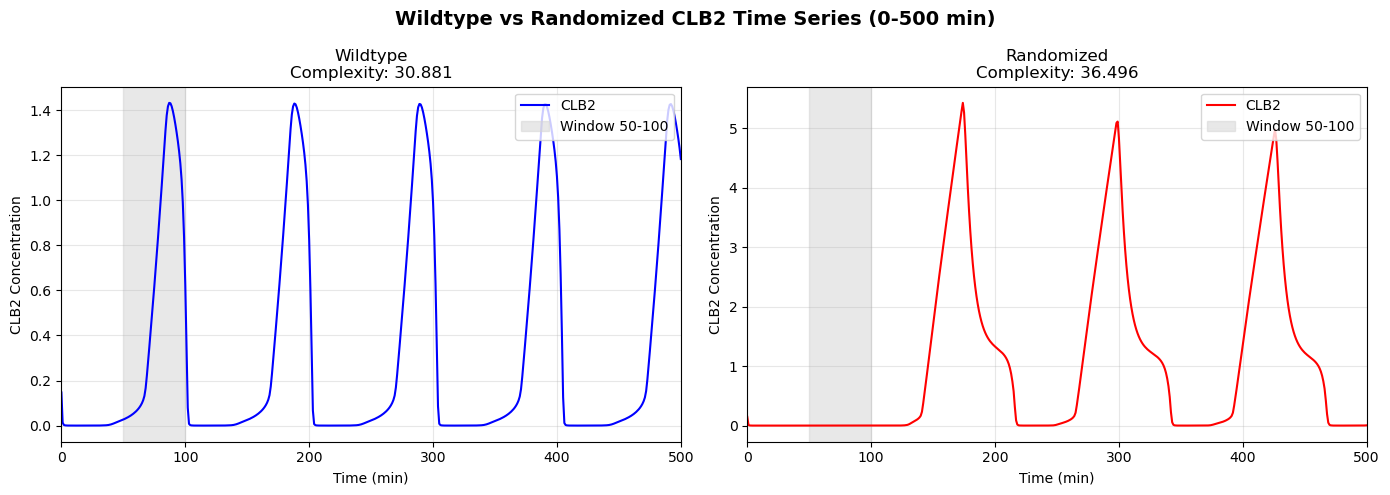

   ✅ Plot saved to plots/wildtype_vs_random_comparison.png


In [ ]:
# === TEST CHICO OSCILLATION APPROACH ===
print("🧪 Testing ChicoOscillation approach...")
print("="*50)

# Create plots directory
os.makedirs('plots', exist_ok=True)

# === GENERATE WILDTYPE REFERENCE DATA ===
print("\n1. Generating wildtype reference data:")
rr_wt = te.loadSBMLModel(model_path)
sampled_wt, values_wt = sample_parameters(rr_wt, wildtype=True)
time_wt, clb2_wt, coarse_data_wt, encoding_wt, complexity_wt = simulate_and_extract_chico(rr_wt, T=T)

# Store wildtype data globally for visualization
WILDTYPE_ENCODING = None
WILDTYPE_COMPLEXITY = None
WILDTYPE_TRAJECTORY_DATA = None

if time_wt is not None and not isinstance(time_wt, str):
    coarse_time_wt, coarse_signal_wt = coarse_data_wt
    
    # Store wildtype reference data
    WILDTYPE_ENCODING = encoding_wt
    WILDTYPE_COMPLEXITY = complexity_wt
    WILDTYPE_TRAJECTORY_DATA = {
        'time': time_wt,
        'clb2': clb2_wt,
        'coarse_time': coarse_time_wt,
        'coarse_signal': coarse_signal_wt,
        'encoding': encoding_wt,
        'complexity': complexity_wt
    }
    
    print(f"   ✅ Wildtype simulation successful")
    print(f"   📊 Time range: {time_wt[0]:.1f} - {time_wt[-1]:.1f} min")
    print(f"   📊 CLB2 range: {np.min(clb2_wt):.3f} - {np.max(clb2_wt):.3f}")
    print(f"   📊 Coarse-grained to {len(coarse_time_wt)} points")
    print(f"   📊 Encoding length: {len(encoding_wt)} bits")
    print(f"   📊 Encoding: {encoding_wt[:30]}...")
    print(f"   📊 Complexity: {complexity_wt:.3f}")
    print(f"   📊 Wildtype data stored for visualization reference")
else:
    print(f"   ❌ Wildtype simulation failed: {time_wt}")

# === GENERATE RANDOMIZED EXAMPLE ===
print("\n2. Testing with randomized parameters:")
rr_rand = te.loadSBMLModel(model_path)
sampled_rand, values_rand = sample_parameters(rr_rand, wildtype=False)
time_rand, clb2_rand, coarse_data_rand, encoding_rand, complexity_rand = simulate_and_extract_chico(rr_rand, T=T)

# Store randomized example for visualization
RANDOMIZED_TRAJECTORY_DATA = None

if time_rand is not None and not isinstance(time_rand, str):
    coarse_time_rand, coarse_signal_rand = coarse_data_rand
    
    # Store randomized example data
    RANDOMIZED_TRAJECTORY_DATA = {
        'time': time_rand,
        'clb2': clb2_rand,
        'coarse_time': coarse_time_rand,
        'coarse_signal': coarse_signal_rand,
        'encoding': encoding_rand,
        'complexity': complexity_rand
    }
    
    print(f"   ✅ Randomized simulation successful")
    print(f"   📊 Time range: {time_rand[0]:.1f} - {time_rand[-1]:.1f} min")
    print(f"   📊 CLB2 range: {np.min(clb2_rand):.3f} - {np.max(clb2_rand):.3f}")
    print(f"   📊 Coarse-grained to {len(coarse_time_rand)} points")
    print(f"   📊 Encoding length: {len(encoding_rand)} bits")
    print(f"   📊 Encoding: {encoding_rand[:30]}...")
    print(f"   📊 Complexity: {complexity_rand:.3f}")
    print(f"   📊 Sample parameters: {values_rand[:5]}...")
    print(f"   📊 Randomized data stored for visualization reference")
else:
    print(f"   ❌ Randomized simulation failed: {time_rand}")



📈 Visualizing ChicoOscillation results...


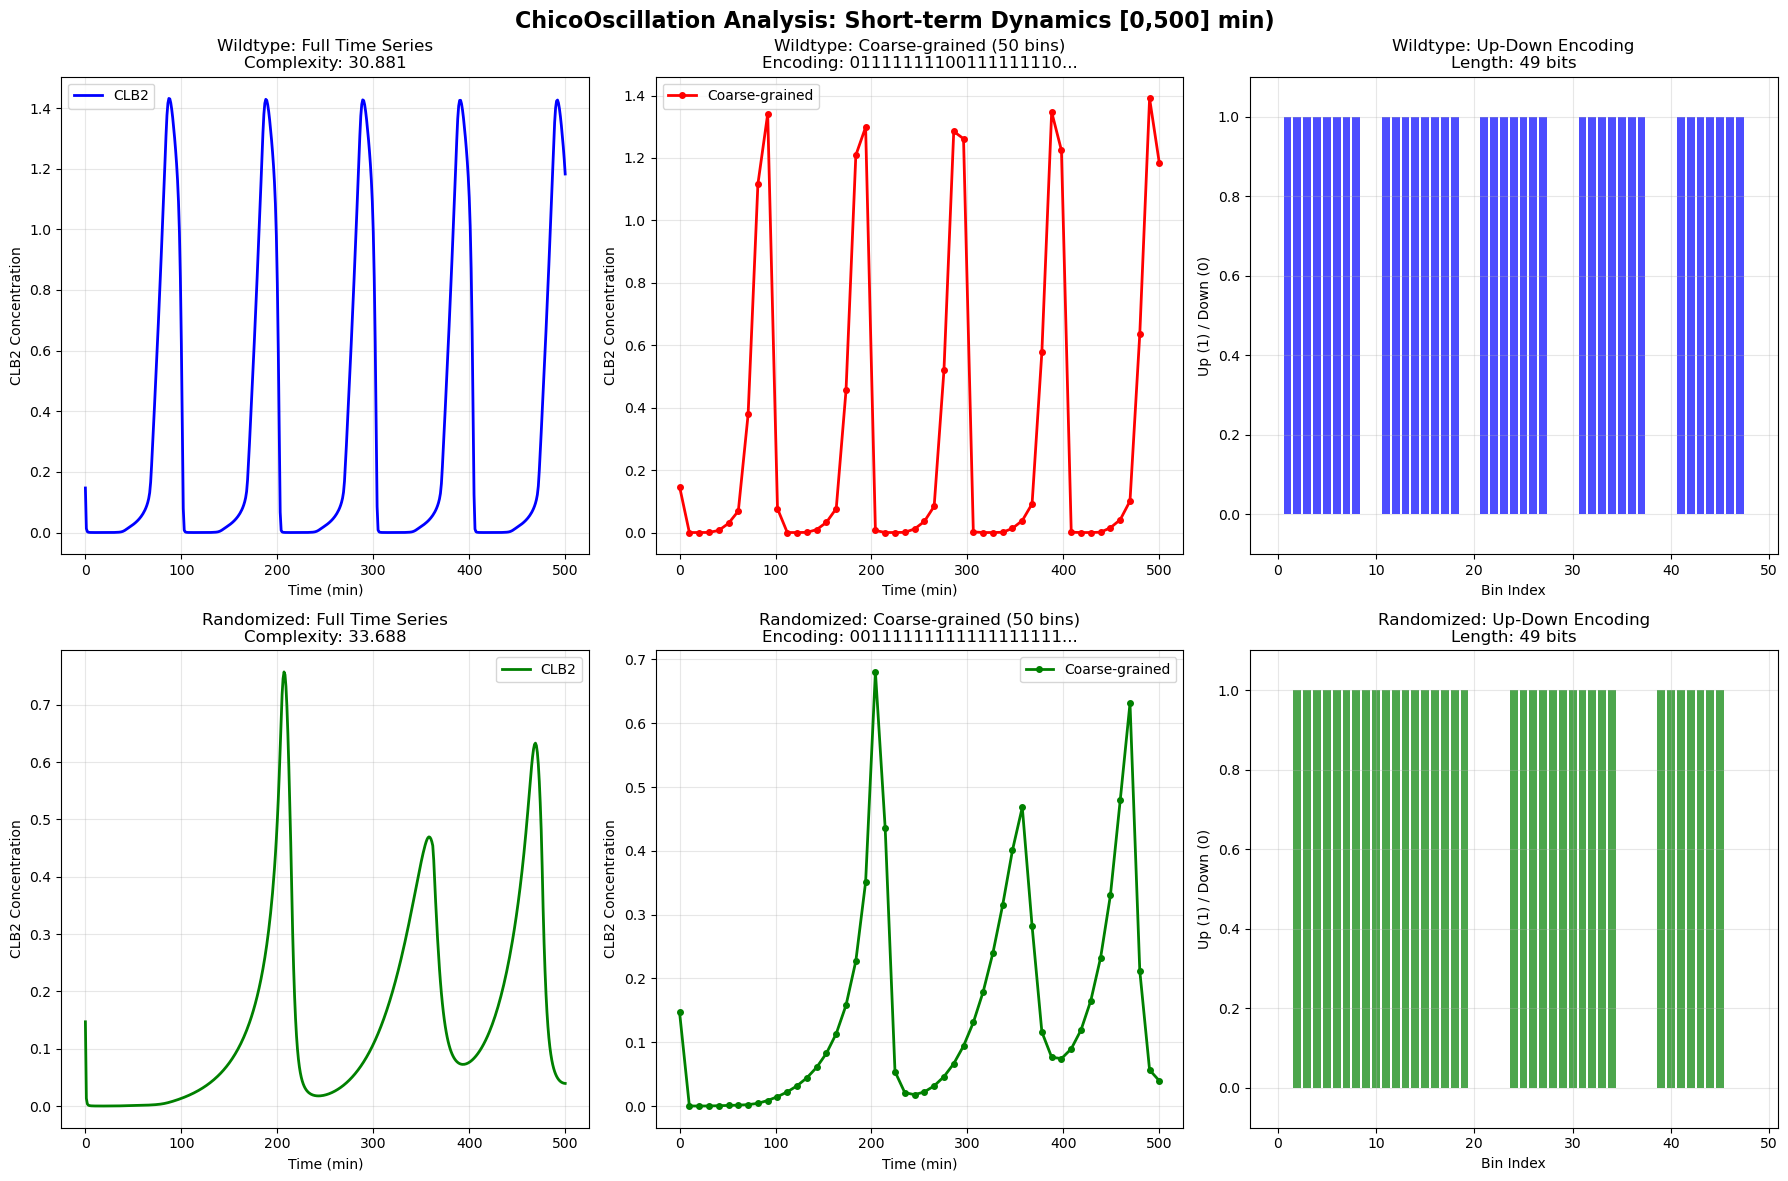


💾 Visualization saved: plots/chico_oscillation_overview.png

📊 CHICO vs CPUHEAVY COMPARISON:
   ChicoOscillation (T=500):
   ├─ Simulation time: 500 min (vs 1000 min in CPUheavy)
   ├─ No oscillation detection required
   ├─ Direct coarse-graining to 50 bins
   ├─ Encoding length: 49 bits
   └─ Focus: Short-term pattern dynamics

   CPUheavy (T=1000):
   ├─ Long simulation for full oscillations
   ├─ Peak detection and period extraction
   ├─ Cycle-based coarse-graining
   └─ Focus: Complete oscillatory behavior


In [13]:
# === VISUALIZATION OF CHICO APPROACH ===
print("📈 Visualizing ChicoOscillation results...")

# Create comprehensive plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'ChicoOscillation Analysis: Short-term Dynamics [{CoarseStart},{CoarseStart+T}] min)', fontsize=16, fontweight='bold')

# Plot 1: Wildtype full time series
if time_wt is not None and not isinstance(time_wt, str):
    axes[0, 0].plot(time_wt, clb2_wt, 'b-', linewidth=2, label='CLB2')
    axes[0, 0].set_title(f'Wildtype: Full Time Series\nComplexity: {complexity_wt:.3f}')
    axes[0, 0].set_xlabel('Time (min)')
    axes[0, 0].set_ylabel('CLB2 Concentration')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

# Plot 2: Wildtype coarse-grained
if time_wt is not None and not isinstance(time_wt, str):
    axes[0, 1].plot(coarse_time_wt, coarse_signal_wt, 'ro-', markersize=4, linewidth=2, label='Coarse-grained')
    axes[0, 1].set_title(f'Wildtype: Coarse-grained ({COARSE_BINS} bins)\nEncoding: {encoding_wt[:20]}...')
    axes[0, 1].set_xlabel('Time (min)')
    axes[0, 1].set_ylabel('CLB2 Concentration')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

# Plot 3: Wildtype encoding visualization
if time_wt is not None and not isinstance(time_wt, str):
    encoding_array = np.array([int(bit) for bit in encoding_wt])
    axes[0, 2].bar(range(len(encoding_array)), encoding_array, alpha=0.7, color='blue')
    axes[0, 2].set_title(f'Wildtype: Up-Down Encoding\nLength: {len(encoding_wt)} bits')
    axes[0, 2].set_xlabel('Bin Index')
    axes[0, 2].set_ylabel('Up (1) / Down (0)')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_ylim(-0.1, 1.1)

# Plot 4: Randomized full time series
if time_rand is not None and not isinstance(time_rand, str):
    axes[1, 0].plot(time_rand, clb2_rand, 'g-', linewidth=2, label='CLB2')
    axes[1, 0].set_title(f'Randomized: Full Time Series\nComplexity: {complexity_rand:.3f}')
    axes[1, 0].set_xlabel('Time (min)')
    axes[1, 0].set_ylabel('CLB2 Concentration')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

# Plot 5: Randomized coarse-grained
if time_rand is not None and not isinstance(time_rand, str):
    axes[1, 1].plot(coarse_time_rand, coarse_signal_rand, 'go-', markersize=4, linewidth=2, label='Coarse-grained')
    axes[1, 1].set_title(f'Randomized: Coarse-grained ({COARSE_BINS} bins)\nEncoding: {encoding_rand[:20]}...')
    axes[1, 1].set_xlabel('Time (min)')
    axes[1, 1].set_ylabel('CLB2 Concentration')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

# Plot 6: Randomized encoding visualization
if time_rand is not None and not isinstance(time_rand, str):
    encoding_array_rand = np.array([int(bit) for bit in encoding_rand])
    axes[1, 2].bar(range(len(encoding_array_rand)), encoding_array_rand, alpha=0.7, color='green')
    axes[1, 2].set_title(f'Randomized: Up-Down Encoding\nLength: {len(encoding_rand)} bits')
    axes[1, 2].set_xlabel('Bin Index')
    axes[1, 2].set_ylabel('Up (1) / Down (0)')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('plots/chico_oscillation_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved: plots/chico_oscillation_overview.png")

# Summary comparison
print(f"\n📊 CHICO vs CPUHEAVY COMPARISON:")
print(f"   ChicoOscillation (T={T}):")
print(f"   ├─ Simulation time: {T} min (vs 1000 min in CPUheavy)")
print(f"   ├─ No oscillation detection required")
print(f"   ├─ Direct coarse-graining to {COARSE_BINS} bins")
print(f"   ├─ Encoding length: {len(encoding_wt) if encoding_wt else 'N/A'} bits")
print(f"   └─ Focus: Short-term pattern dynamics")
print(f"")
print(f"   CPUheavy (T=1000):")
print(f"   ├─ Long simulation for full oscillations")
print(f"   ├─ Peak detection and period extraction")
print(f"   ├─ Cycle-based coarse-graining")
print(f"   └─ Focus: Complete oscillatory behavior")

In [9]:
# === BATCH PROCESSING WITH PARALLELIZATION ===
# (Adapted from CPUheavy with ChicoOscillation modifications)

def process_batch_chico_worker(args):
    """Worker function for parallel ChicoOscillation processing"""
    batch_start, batch_size, model_path_worker, T_worker = args
    
    # Initialize results for this batch
    batch_results = {
        'encodings': [],
        'complexities': [],
        'divergent_count': 0,
        'success_count': 0,
        'tracked_data': []
    }
    
    try:
        # Load model in worker process
        rr_worker = te.loadSBMLModel(model_path_worker)
        kinetic_params, excluded_params = get_kinetic_parameters_cached(rr_worker)
        
        # Cache default parameter values
        default_values = {}
        for pid in rr_worker.getGlobalParameterIds():
            default_values[pid] = rr_worker.getValue(pid)
        
        # Process batch
        for i in range(batch_size):
            # Reset and randomize parameters
            sampled_params, sampled_values = sample_parameters_fast(
                rr_worker, kinetic_params, default_values, wildtype=False
            )
            
            # Run ChicoOscillation analysis
            time_data, clb2_data, coarse_data, encoding, complexity = simulate_and_extract_chico(
                rr_worker, T=T_worker
            )
            
            # Classify result
            if isinstance(time_data, str) and time_data == "divergent":
                batch_results['divergent_count'] += 1
            elif time_data is None or encoding is None:
                batch_results['divergent_count'] += 1  # Count as divergent
            else:
                # Success: store results
                batch_results['success_count'] += 1
                batch_results['encodings'].append(encoding)
                batch_results['complexities'].append(complexity)
                
                # Store minimal data for tracking
                if len(batch_results['tracked_data']) < N_TRACK_PHENOTYPES * 3:
                    phenotype_data = {
                        'time_data': time_data,
                        'clb2_data': clb2_data,
                        'coarse_data': coarse_data,
                        'encoding': encoding,
                        'complexity': complexity
                    }
                    lightweight_genotype = {f'param_{j}': val for j, val in enumerate(sampled_values)}
                    batch_results['tracked_data'].append((encoding, lightweight_genotype, phenotype_data))
        
        return batch_results
        
    except Exception as e:
        print(f"Worker error: {e}")
        return batch_results

def merge_batch_results_chico(all_results):
    """Merge results from all ChicoOscillation worker batches"""
    merged = {
        'encodings': [],
        'complexities': [],
        'divergent_count': 0,
        'success_count': 0,
        'tracked_data': []
    }
    
    for batch_result in all_results:
        merged['encodings'].extend(batch_result['encodings'])
        merged['complexities'].extend(batch_result['complexities'])
        merged['divergent_count'] += batch_result['divergent_count']
        merged['success_count'] += batch_result['success_count']
        merged['tracked_data'].extend(batch_result['tracked_data'])
    
    return merged

print("✓ ChicoOscillation batch processing functions defined!")
print(f"   - Optimized for T={T} min simulations")
print(f"   - Parallel processing with {NUM_WORKERS} workers")
print(f"   - Batch size: {BATCH_SIZE}")

✓ ChicoOscillation batch processing functions defined!
   - Optimized for T=500 min simulations
   - Parallel processing with 7 workers
   - Batch size: 1000


In [10]:
# === RUN CHICO OSCILLATION ANALYSIS ===
print("🚀 RUNNING CHICO OSCILLATION ANALYSIS")
print("="*50)
print(f"📊 Analyzing {SAMPLING_SIZE:,} samples with T={T} min")
print(f"🔧 Using {NUM_WORKERS} parallel workers")
print(f"📦 Batch size: {BATCH_SIZE}")

import time
from collections import Counter

# Initialize counters
all_results = []
divergent_count = 0
success_count = 0

start_time = time.time()

# Prepare batches for parallel processing
num_batches = (SAMPLING_SIZE + BATCH_SIZE - 1) // BATCH_SIZE
batches = []

for i in range(num_batches):
    batch_start = i * BATCH_SIZE
    current_batch_size = min(BATCH_SIZE, SAMPLING_SIZE - batch_start)
    batches.append((batch_start, current_batch_size, model_path, T))

print(f"📋 Created {len(batches)} batches for processing")

# Run parallel processing
if USE_MULTIPROCESSING and USE_PROCESS_POOL:
    print(f"🔄 Running parallel analysis with ProcessPoolExecutor...")
    
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        # Submit all batches
        future_to_batch = {executor.submit(process_batch_chico_worker, batch_args): i 
                          for i, batch_args in enumerate(batches)}
        
        completed_batches = 0
        
        # Process completed batches
        for future in as_completed(future_to_batch):
            batch_idx = future_to_batch[future]
            
            try:
                result = future.result()
                all_results.append(result)
                completed_batches += 1
                
                # Progress update
                samples_processed = sum(len(r['encodings']) + r['divergent_count'] for r in all_results)
                elapsed = time.time() - start_time
                rate = samples_processed / elapsed if elapsed > 0 else 0
                progress = completed_batches / len(batches) * 100
                
                if completed_batches % max(1, len(batches) // 10) == 0:  # Update every 10%
                    print(f"   Progress: {completed_batches}/{len(batches)} batches ({progress:.1f}%) | "
                          f"Processed: {samples_processed:,} | Rate: {rate:.1f} samples/s")
                
            except Exception as e:
                print(f"Batch {batch_idx} failed: {e}")
                # Add empty result to maintain count
                all_results.append({'encodings': [], 'complexities': [], 'divergent_count': 0, 
                                  'success_count': 0, 'tracked_data': []})
                completed_batches += 1

else:
    print(f"🔄 Running serial analysis (multiprocessing disabled)...")
    for i, batch_args in enumerate(batches):
        result = process_batch_chico_worker(batch_args)
        all_results.append(result)
        
        if (i + 1) % max(1, len(batches) // 10) == 0:
            progress = (i + 1) / len(batches) * 100
            samples_processed = sum(len(r['encodings']) + r['divergent_count'] for r in all_results)
            elapsed = time.time() - start_time
            rate = samples_processed / elapsed if elapsed > 0 else 0
            print(f"   Progress: {i+1}/{len(batches)} batches ({progress:.1f}%) | "
                  f"Processed: {samples_processed:,} | Rate: {rate:.1f} samples/s")

# Merge all results
print(f"\n📊 Merging results from {len(all_results)} batches...")
merged_results = merge_batch_results_chico(all_results)

# Extract final results
encodings = merged_results['encodings']
complexities = merged_results['complexities']
divergent_count = merged_results['divergent_count']
success_count = merged_results['success_count']

processing_time = time.time() - start_time

print(f"\n✅ CHICO OSCILLATION ANALYSIS COMPLETED!")
print(f"   ⏱️  Total time: {processing_time:.1f}s ({processing_time/60:.1f}m)")
print(f"   📊 Success: {success_count:,}/{SAMPLING_SIZE:,} ({success_count/SAMPLING_SIZE*100:.1f}%)")
print(f"   🚫 Divergent: {divergent_count:,} ({divergent_count/SAMPLING_SIZE*100:.1f}%)")
print(f"   ⚡ Processing rate: {SAMPLING_SIZE/processing_time:.1f} samples/s")

if success_count > 0:
    complexity_array = np.array(complexities)
    print(f"\n📈 COMPLEXITY STATISTICS:")
    print(f"   Min complexity: {np.min(complexity_array):.3f}")
    print(f"   Max complexity: {np.max(complexity_array):.3f}")
    print(f"   Mean complexity: {np.mean(complexity_array):.3f} ± {np.std(complexity_array):.3f}")
    print(f"   Median complexity: {np.median(complexity_array):.3f}")
else:
    print(f"\n❌ No successful simulations - all diverged!")

🚀 RUNNING CHICO OSCILLATION ANALYSIS
📊 Analyzing 100,000 samples with T=500 min
🔧 Using 7 parallel workers
📦 Batch size: 1000
📋 Created 100 batches for processing
🔄 Running parallel analysis with ProcessPoolExecutor...
Batch 0 failed: A process in the process pool was terminated abruptly while the future was running or pending.
Batch 1 failed: A process in the process pool was terminated abruptly while the future was running or pending.
Batch 2 failed: A process in the process pool was terminated abruptly while the future was running or pending.
Batch 3 failed: A process in the process pool was terminated abruptly while the future was running or pending.
Batch 4 failed: A process in the process pool was terminated abruptly while the future was running or pending.
Batch 5 failed: A process in the process pool was terminated abruptly while the future was running or pending.
Batch 6 failed: A process in the process pool was terminated abruptly while the future was running or pending.
Batc

Process SpawnProcess-3:
Process SpawnProcess-7:
Process SpawnProcess-4:
Process SpawnProcess-5:
Process SpawnProcess-1:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process SpawnProcess-6:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/queues.py",

In [11]:
# === CHICO OSCILLATION RESULTS VISUALIZATION ===
print("📈 Creating ChicoOscillation complexity analysis visualization...")

if success_count > 0:
    # Calculate phenotype frequencies
    phenotype_counts = Counter(encodings)
    complexities_array = np.array(complexities)
    
    # Prepare data for plotting
    phenotype_complexities = []
    phenotype_frequencies = []
    
    for phenotype, frequency in phenotype_counts.items():
        complexity = CLZ(phenotype)
        phenotype_complexities.append(complexity)
        phenotype_frequencies.append(frequency)
    
    # Get wildtype complexity and frequency from stored data
    if WILDTYPE_ENCODING is not None and WILDTYPE_COMPLEXITY is not None:
        wildtype_complexity = WILDTYPE_COMPLEXITY
        wildtype_frequency = phenotype_counts.get(WILDTYPE_ENCODING, 0)
        if wildtype_frequency == 0:
            wildtype_frequency = 1  # Set to 1 if wildtype not found in random samples
        print(f"   Using stored wildtype: complexity={wildtype_complexity:.3f}, frequency={wildtype_frequency}")
    else:
        # Fallback: calculate wildtype on the fly
        print("   Warning: No stored wildtype data, calculating fresh wildtype...")
        rr_wt_temp = te.loadSBMLModel(model_path)
        sample_parameters(rr_wt_temp, wildtype=True)
        _, _, _, encoding_temp, complexity_temp = simulate_and_extract_chico(rr_wt_temp, T=T)
        wildtype_complexity = complexity_temp if complexity_temp else 19.651  # fallback value
        wildtype_frequency = phenotype_counts.get(encoding_temp, 1) if encoding_temp else 1
    
    # === PLOT 1: COMPLEXITY ANALYSIS ===
    # Filter settings
    FILTER_SINGLE_OCCURRENCES = True  # Remove frequency = 1 points
    MIN_COMPLEXITY_THRESHOLD = 0   # Minimum complexity to display
    APPLY_COMPLEXITY_FILTER = True    # Toggle for complexity filtering
    
    # Filter data for plotting
    filtered_complexities = []
    filtered_frequencies = []
    
    for complexity, frequency in zip(phenotype_complexities, phenotype_frequencies):
        # Apply filters
        if FILTER_SINGLE_OCCURRENCES and frequency == 1:
            continue  # Skip single occurrences
        if APPLY_COMPLEXITY_FILTER and complexity < MIN_COMPLEXITY_THRESHOLD:
            continue  # Skip low complexity
        
        filtered_complexities.append(complexity)
        filtered_frequencies.append(frequency)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Scatter plot of filtered complexity vs frequency
    if filtered_complexities:
        scatter = ax.scatter(filtered_complexities, filtered_frequencies, 
                            alpha=0.6, s=40, c='black', 
                            edgecolors='gray', linewidth=0.5,
                            label='Random Genotypes')
        
        # Add purple convex hull around high-complexity scatter points
        from scipy.spatial import ConvexHull
        
        # Filter points for hull calculation (complexity >= 10)
        hull_complexities = []
        hull_frequencies = []
        for complexity, frequency in zip(filtered_complexities, filtered_frequencies):
            if complexity >= 10.0:  # Only include points with complexity >= 10
                hull_complexities.append(complexity)
                hull_frequencies.append(frequency)
        
        if len(hull_complexities) >= 3:  # Need at least 3 points for a hull
            try:
                # Create custom hull shape based on max frequency at each complexity
                # Group points by complexity bins and find max frequency for each bin
                complexity_bins = {}
                for complexity, frequency in zip(hull_complexities, hull_frequencies):
                    comp_bin = round(complexity, 1)  # Round to nearest 0.1
                    if comp_bin not in complexity_bins:
                        complexity_bins[comp_bin] = []
                    complexity_bins[comp_bin].append(frequency)
                
                # Get max and min frequency (>1) for each complexity bin
                hull_x_coords = []
                hull_y_max = []
                hull_y_min = []
                
                for comp_bin in sorted(complexity_bins.keys()):
                    frequencies = complexity_bins[comp_bin]
                    # Filter frequencies > 1 for minimum
                    frequencies_filtered = [f for f in frequencies if f > 1]
                    
                    max_freq = max(frequencies)
                    min_freq = min(frequencies_filtered) if frequencies_filtered else min(frequencies)
                    
                    hull_x_coords.append(comp_bin)
                    hull_y_max.append(max_freq)
                    hull_y_min.append(min_freq)
                
                # Create hull outline by connecting max points and min points
                if len(hull_x_coords) >= 2:
                    # Create closed polygon: left to right along top, then right to left along bottom
                    hull_x_final = hull_x_coords + hull_x_coords[::-1]  # Forward then backward
                    hull_y_final = hull_y_max + hull_y_min[::-1]  # Max frequencies then min frequencies reversed
                    
                    # Subtle hull outline and fill
                    ax.plot(hull_x_final, hull_y_final, 'lightgray', linewidth=1, alpha=0.5)
                    ax.fill(hull_x_final, hull_y_final, 'purple', alpha=0.25)
                    
                    # Mark the max and min frequency points with subtle markers
                    ax.scatter(hull_x_coords, hull_y_max, 
                              color='purple', s=30, marker='^', edgecolors='purple', 
                              linewidth=0.5, alpha=0.6, zorder=9, label='Max freq per complexity')
                    ax.scatter(hull_x_coords, hull_y_min, 
                              color='darkviolet', s=20, marker='v', edgecolors='darkviolet', 
                              linewidth=0.5, alpha=0.6, zorder=9, label='Min freq>1 per complexity')
                    
                    print(f"   Purple hull computed with {len(hull_x_coords)} complexity bins from {len(hull_complexities)} high-complexity points (C≥10)")
                    print(f"   Hull envelope: max frequencies and min frequencies>1 for each complexity")
                else:
                    print(f"   Note: Only {len(hull_x_coords)} complexity bins with C≥10, need at least 2 for hull")
                
            except Exception as e:
                print(f"   Note: Could not compute custom hull: {e}")
        else:
            print(f"   Note: Only {len(hull_complexities)} points with complexity ≥ 10, need at least 3 for hull")
    
    # Add wildtype as red dot (always show regardless of filters)
    ax.scatter(wildtype_complexity, wildtype_frequency, 
              color='red', s=60, marker='o', edgecolors='darkred', 
              linewidth=1, zorder=10, label='Wildtype')
    
    # Formatting
    ax.set_xlabel('Lempel-Ziv Complexity', fontsize=14)
    ax.set_ylabel('Phenotype Frequency', fontsize=14)
    
    # Update title to reflect filtering
    filter_text = ""
    if FILTER_SINGLE_OCCURRENCES:
        filter_text += "freq>1, "
    if APPLY_COMPLEXITY_FILTER:
        filter_text += f"C≥{MIN_COMPLEXITY_THRESHOLD}, "
    filter_text = filter_text.rstrip(", ")
    
    if filter_text:
        title_text = f'ChicoOscillation Complexity Analysis (Filtered: {filter_text})\n [{CoarseStart},{CoarseStart+T}] min, {len(filtered_complexities):,}/{success_count:,} Fenotypes (>1)/Genotypes, {len(phenotype_counts):,} unique phenotypes'
    else:
        title_text = f'ChicoOscillation Complexity Analysis\nT={T} min, {success_count:,} samples, {len(phenotype_counts):,} unique phenotypes'
    
    ax.set_title(title_text, fontsize=16, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('plots/chico_oscillation_complexity_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # === PLOT 2: LOG-LOG RANK FREQUENCY PLOT ===
    # Prepare rank-frequency data
    frequencies_sorted = sorted(phenotype_counts.values(), reverse=True)
    ranks = np.arange(1, len(frequencies_sorted) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.loglog(ranks, frequencies_sorted, marker='o', linestyle='none', markersize=3)
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.title(f"Log-Log Plot of Phenotype String Frequency by Rank\nChico Model, N={len(encodings):,} samples ({processing_time/60:.1f}min, {SAMPLING_SIZE/processing_time:.1f}/s)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"plots/Chico_rank_frequency_loglog_N{len(encodings)}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # === PLOT 3: WILDTYPE VS RANDOMIZED COMPARISON ===
    # Use stored trajectory data from the test section
    if (WILDTYPE_TRAJECTORY_DATA is not None and RANDOMIZED_TRAJECTORY_DATA is not None):
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'ChicoOscillation: Wildtype vs Randomized Comparison [{CoarseStart},{CoarseStart+T}] min)', fontsize=16, fontweight='bold')
        
        # Extract stored wildtype data
        wt_data = WILDTYPE_TRAJECTORY_DATA
        rand_data = RANDOMIZED_TRAJECTORY_DATA
        
        # Wildtype plots
        axes[0, 0].plot(wt_data['time'], wt_data['clb2'], 'b-', linewidth=1)
        axes[0, 0].set_title("Wildtype: Full Trajectory")
        axes[0, 0].set_xlabel("Time (min)")
        axes[0, 0].set_ylabel("CLB2")
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(wt_data['coarse_time'] - wt_data['coarse_time'][0], wt_data['coarse_signal'], 'ro-', markersize=3, linewidth=2)
        axes[0, 1].set_title(f"Wildtype: Coarse-grained ({COARSE_BINS} bins)")
        axes[0, 1].set_xlabel("Time (min)")
        axes[0, 1].set_ylabel("CLB2")
        axes[0, 1].grid(True, alpha=0.3)
        
        step_time = np.linspace(0, 1, len(wt_data['encoding']))
        encoding_values_wt = [int(bit) for bit in wt_data['encoding']]
        axes[0, 2].step(step_time, encoding_values_wt, 'g-', linewidth=2, where='post')
        axes[0, 2].fill_between(step_time, 0, encoding_values_wt, step='post', alpha=0.3, color='green')
        axes[0, 2].set_title(f"Wildtype: Encoding (CLZ: {wt_data['complexity']:.3f})")
        axes[0, 2].set_xlabel("Normalized time")
        axes[0, 2].set_ylabel("Slope sign")
        axes[0, 2].set_ylim(-0.1, 1.1)
        axes[0, 2].grid(True, alpha=0.3)
        
        # Randomized plots
        axes[1, 0].plot(rand_data['time'], rand_data['clb2'], 'b-', linewidth=1)
        axes[1, 0].set_title("Randomized: Full Trajectory")
        axes[1, 0].set_xlabel("Time (min)")
        axes[1, 0].set_ylabel("CLB2")
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(rand_data['coarse_time'] - rand_data['coarse_time'][0], rand_data['coarse_signal'], 'ro-', markersize=3, linewidth=2)
        axes[1, 1].set_title(f"Randomized: Coarse-grained ({COARSE_BINS} bins)")
        axes[1, 1].set_xlabel("Time (min)")
        axes[1, 1].set_ylabel("CLB2")
        axes[1, 1].grid(True, alpha=0.3)
        
        step_time_rand = np.linspace(0, 1, len(rand_data['encoding']))
        encoding_values_rand = [int(bit) for bit in rand_data['encoding']]
        axes[1, 2].step(step_time_rand, encoding_values_rand, 'g-', linewidth=2, where='post')
        axes[1, 2].fill_between(step_time_rand, 0, encoding_values_rand, step='post', alpha=0.3, color='green')
        axes[1, 2].set_title(f"Randomized: Encoding (CLZ: {rand_data['complexity']:.3f})")
        axes[1, 2].set_xlabel("Normalized time")
        axes[1, 2].set_ylabel("Slope sign")
        axes[1, 2].set_ylim(-0.1, 1.1)
        axes[1, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('plots/chico_oscillation_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n💾 Comparison plot saved: plots/chico_oscillation_comparison.png")
    else:
        print(f"\n⚠️  Skipping comparison plot - no stored trajectory data available")
        print(f"    Run the test cell first to generate reference trajectories")
    
    print(f"\n💾 Complexity analysis saved: plots/chico_oscillation_complexity_analysis.png")
    print(f"💾 Rank-frequency plot saved: plots/Chico_rank_frequency_loglog_N{len(encodings)}.png")
    
    # Print summary statistics
    print(f"\n📊 CHICO OSCILLATION COMPLEXITY SUMMARY:")
    print(f"   🎯 Simulation approach: Direct coarse-graining (no oscillation detection)")
    print(f"   ⏱️  Simulation time: {T} min per sample")
    print(f"   📏 Encoding length: {COARSE_BINS-1} bits (consistent)")
    print(f"   🧬 Unique phenotypes: {len(phenotype_counts):,}")
    print(f"   📈 Complexity range: {np.min(complexities_array):.3f} - {np.max(complexities_array):.3f}")
    print(f"   📈 Mean complexity: {np.mean(complexities_array):.3f} ± {np.std(complexities_array):.3f}")
    print(f"   🔴 Wildtype complexity: {wildtype_complexity:.3f} (frequency: {wildtype_frequency})")
    print(f"   ⚡ Processing efficiency: {SAMPLING_SIZE/processing_time:.1f} samples/second")

else:
    print(f"❌ Cannot create visualization - no successful simulations")
    print(f"   All {SAMPLING_SIZE:,} samples diverged")
    print(f"   Consider adjusting parameters or divergence threshold")

    

📈 Creating ChicoOscillation complexity analysis visualization...
❌ Cannot create visualization - no successful simulations
   All 100,000 samples diverged
   Consider adjusting parameters or divergence threshold


🚀 RUNNING MULTI-WINDOW COMPLEXITY ANALYSIS
📊 Analyzing 6 different time windows
📊 1,000,000 samples per window
🔧 Using 7 parallel workers

🔄 Processing window 1/6: [0, 50] min


Process SpawnProcess-8:
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_batch_chico_worker' on <module '__main__' (built-in)>
Process SpawnProcess-9:
Traceback (most recent call last):


   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or p

Process SpawnProcess-15:
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_batch_chico_worker' on <module '__main__' (built-in)>
Process SpawnProcess-16:
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/sh

   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or p

...

   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or p

Process SpawnProcess-36:
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_batch_chico_worker' on <module '__main__' (built-in)>
Process SpawnProcess-37:
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/sh

   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or p

Process SpawnProcess-43:
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_batch_chico_worker' on <module '__main__' (built-in)>
Process SpawnProcess-44:
Traceback (most recent call last):
  File "/Users/gijsbartholomeus/.local/sh

   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or pending.
   Batch failed: A process in the process pool was terminated abruptly while the future was running or p

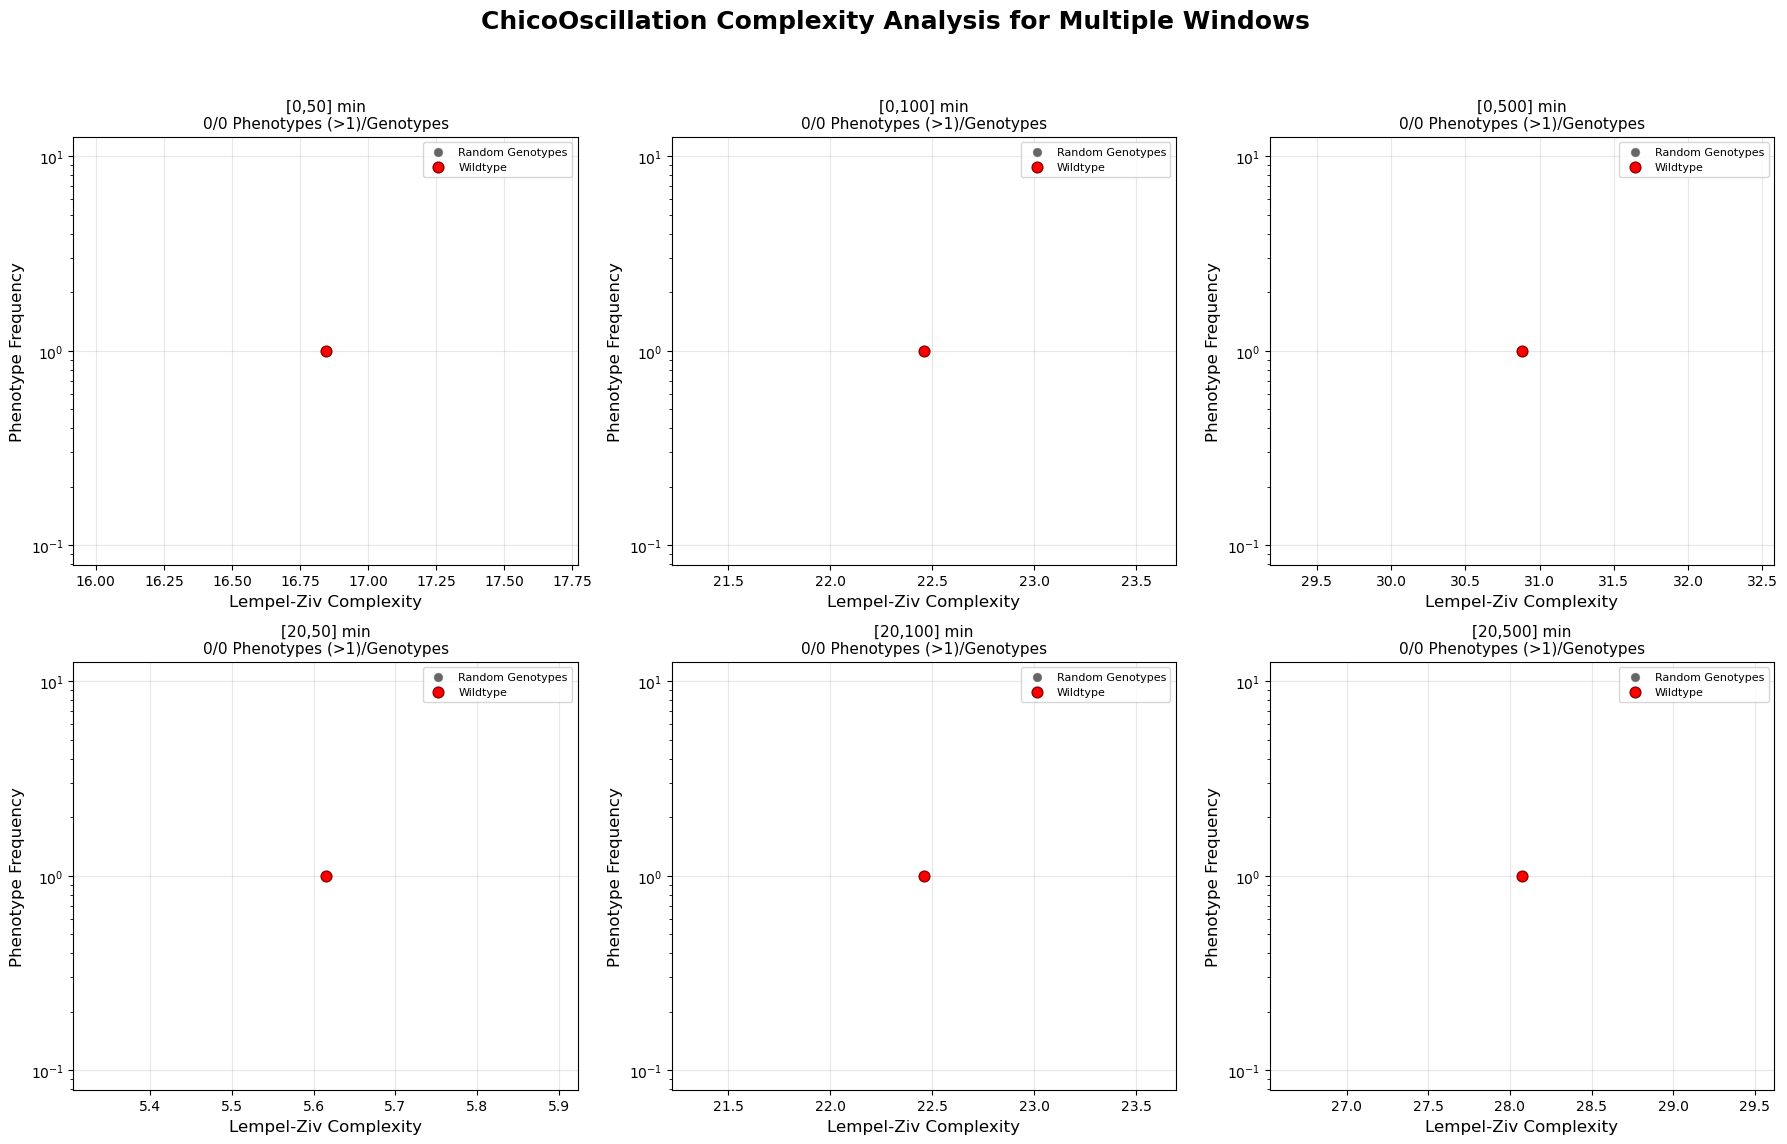


✅ MULTI-WINDOW ANALYSIS COMPLETED!
💾 Plot saved: plots/chico_multi_window_analysis.png

✅ MULTI-WINDOW ANALYSIS COMPLETED!
💾 Plot saved: plots/chico_multi_window_analysis.png

🔄 Creating frequency rank plots for all windows...
   (Reusing data from complexity analysis - no recalculation needed)


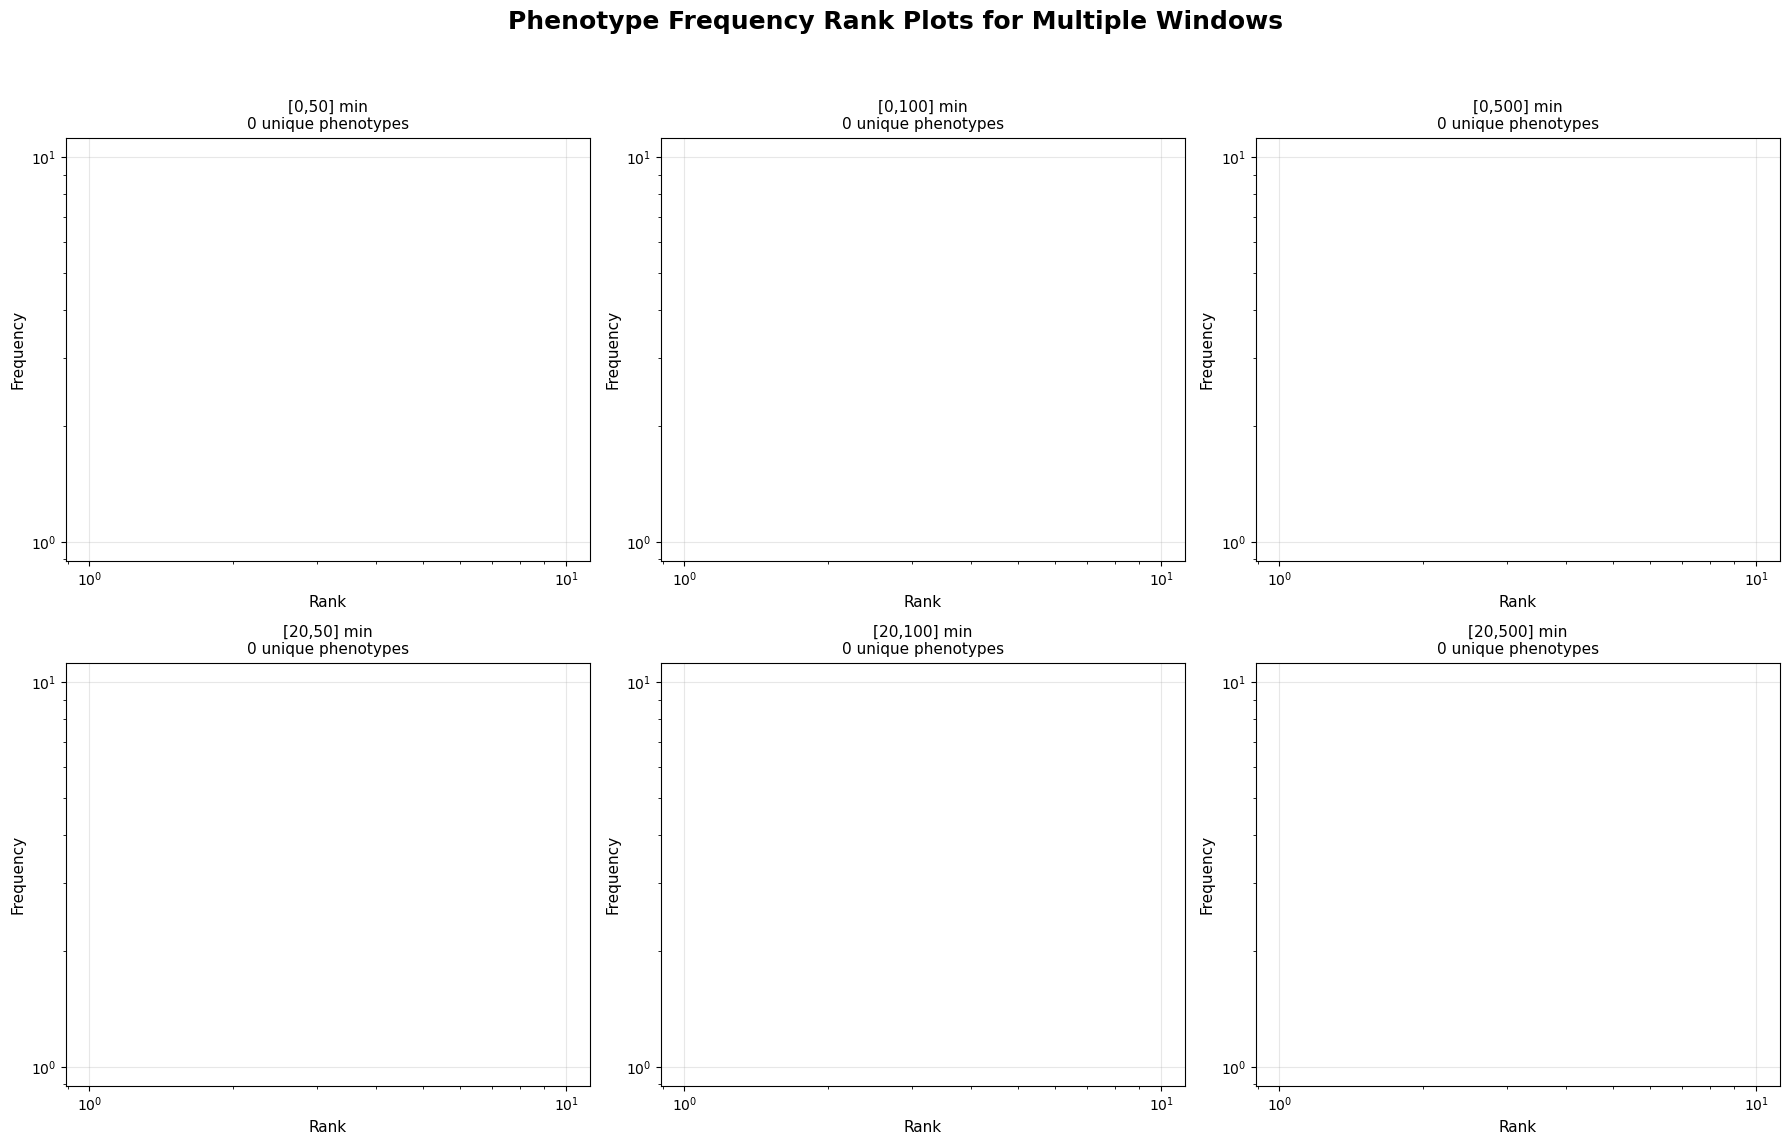


💾 Rank plots saved: plots/chico_multi_window_rank_plots.png


In [ ]:
# === MULTI-WINDOW COMPLEXITY PHENOTYPE ANALYSIS WITH PURPLE HULL SUBPLOTS ===
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import time

# Define window ranges
windows = [(0, 50), (0, 100), (0, 500), (20,50), (20, 100), (20, 500)]
SAMPLING_SIZE_WINDOWS = 10**6  # Number of samples per window
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Storage for reusing data in rank plots
windows_data_storage = []

print("🚀 RUNNING MULTI-WINDOW COMPLEXITY ANALYSIS")
print("="*60)
print(f"📊 Analyzing {len(windows)} different time windows")
print(f"📊 {SAMPLING_SIZE_WINDOWS:,} samples per window")
print(f"🔧 Using {NUM_WORKERS} parallel workers")

for idx, (start, end) in enumerate(windows):
    print(f"\n{'='*60}")
    print(f"🔄 Processing window {idx+1}/{len(windows)}: [{start}, {end}] min")
    print(f"{'='*60}")
    
    # Run optimized batch processing for this window
    all_results = []
    start_time = time.time()
    
    # Prepare batches
    num_batches = (SAMPLING_SIZE_WINDOWS + BATCH_SIZE - 1) // BATCH_SIZE
    batches = []
    
    for i in range(num_batches):
        batch_start = i * BATCH_SIZE
        current_batch_size = min(BATCH_SIZE, SAMPLING_SIZE_WINDOWS - batch_start)
        batches.append((batch_start, current_batch_size, model_path, end))
    
    # Run parallel processing with optimized worker
    if USE_MULTIPROCESSING and USE_PROCESS_POOL:
        with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
            future_to_batch = {executor.submit(process_batch_chico_worker, batch_args): i 
                              for i, batch_args in enumerate(batches)}
            
            completed_batches = 0
            for future in as_completed(future_to_batch):
                try:
                    result = future.result()
                    all_results.append(result)
                    completed_batches += 1
                    
                    if completed_batches % max(1, len(batches) // 5) == 0:
                        progress = completed_batches / len(batches) * 100
                        print(f"   Progress: {completed_batches}/{len(batches)} batches ({progress:.1f}%)")
                except Exception as e:
                    print(f"   Batch failed: {e}")
                    all_results.append({'encodings': [], 'complexities': [], 'divergent_count': 0, 
                                      'success_count': 0, 'tracked_data': []})
    else:
        for i, batch_args in enumerate(batches):
            result = process_batch_chico_worker(batch_args)
            all_results.append(result)
    
    # Merge results
    merged_results = merge_batch_results_chico(all_results)
    encodings = merged_results['encodings']
    complexities = merged_results['complexities']
    success_count = merged_results['success_count']
    processing_time = time.time() - start_time
    
    print(f"   ✅ Completed: {success_count:,} successful samples in {processing_time:.1f}s ({success_count/processing_time:.1f} samples/s)")
    
    # Calculate wildtype for this window
    rr_wt_window = te.loadSBMLModel(model_path)
    sample_parameters(rr_wt_window, wildtype=True)
    _, _, _, wt_encoding, wt_complexity = simulate_and_extract_chico(rr_wt_window, T=end, CoarseStart=start)
    
    # Process results for plotting
    phenotype_counts = Counter(encodings)
    phenotype_complexities = [CLZ(p) for p in phenotype_counts.keys()]
    phenotype_frequencies = list(phenotype_counts.values())
    wildtype_complexity = wt_complexity if wt_complexity else 0
    wildtype_frequency = phenotype_counts.get(wt_encoding, 1) if wt_encoding else 1
    
    # Store data for rank plots (to avoid recalculating)
    windows_data_storage.append({
        'window': (start, end),
        'phenotype_counts': phenotype_counts,
        'success_count': success_count
    })
    
    # Filter for plotting: complexity > 10 and frequency > 1
    filtered_complexities = []
    filtered_frequencies = []
    for c, f in zip(phenotype_complexities, phenotype_frequencies):
        if f > 1 and c > 10.0:  # Changed from c >= 0 to c > 10.0
            filtered_complexities.append(c)
            filtered_frequencies.append(f)
    
    # Plot scatter
    ax = axes[idx]
    ax.scatter(filtered_complexities, filtered_frequencies, alpha=0.6, s=40, c='black', 
               edgecolors='gray', linewidth=0.5, label='Random Genotypes')
    
    # Purple hull (already filtered to complexity > 10)
    hull_complexities = filtered_complexities  # Use already filtered data
    hull_frequencies = filtered_frequencies
    if len(hull_complexities) >= 3:
        complexity_bins = {}
        for c, f in zip(hull_complexities, hull_frequencies):
            comp_bin = round(c, 1)
            if comp_bin not in complexity_bins:
                complexity_bins[comp_bin] = []
            complexity_bins[comp_bin].append(f)
        hull_x_coords = []
        hull_y_max = []
        hull_y_min = []
        for comp_bin in sorted(complexity_bins.keys()):
            frequencies = complexity_bins[comp_bin]
            frequencies_filtered = [ff for ff in frequencies if ff > 1]
            max_freq = max(frequencies)
            min_freq = min(frequencies_filtered) if frequencies_filtered else min(frequencies)
            hull_x_coords.append(comp_bin)
            hull_y_max.append(max_freq)
            hull_y_min.append(min_freq)
        if len(hull_x_coords) >= 2:
            hull_x_final = hull_x_coords + hull_x_coords[::-1]
            hull_y_final = hull_y_max + hull_y_min[::-1]
            ax.plot(hull_x_final, hull_y_final, 'lightgray', linewidth=1, alpha=0.5)
            ax.fill(hull_x_final, hull_y_final, 'purple', alpha=0.25)
            ax.scatter(hull_x_coords, hull_y_max, color='purple', s=30, marker='^', 
                      edgecolors='purple', linewidth=0.5, alpha=0.6, zorder=9)
            ax.scatter(hull_x_coords, hull_y_min, color='darkviolet', s=20, marker='v', 
                      edgecolors='darkviolet', linewidth=0.5, alpha=0.6, zorder=9)
    
    # Wildtype in red
    ax.scatter(wildtype_complexity, wildtype_frequency, color='red', s=60, marker='o', 
              edgecolors='darkred', linewidth=1, zorder=10, label='Wildtype')
    ax.set_xlabel('Lempel-Ziv Complexity', fontsize=12)
    ax.set_ylabel('Phenotype Frequency', fontsize=12)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(f'[{start},{end}] min\n{len(filtered_complexities)}/{success_count} Phenotypes (>1)/Genotypes', 
                fontsize=11)

fig.suptitle('ChicoOscillation Complexity Analysis for Multiple Windows', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('plots/chico_multi_window_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("✅ MULTI-WINDOW ANALYSIS COMPLETED!")
print(f"💾 Plot saved: plots/chico_multi_window_analysis.png")
print(f"{'='*60}")

print(f"\n{'='*60}")
print("✅ MULTI-WINDOW ANALYSIS COMPLETED!")
print(f"💾 Plot saved: plots/chico_multi_window_analysis.png")
print(f"{'='*60}")

# === FREQUENCY RANK PLOTS FOR ALL WINDOWS (REUSING DATA) ===
print(f"\n🔄 Creating frequency rank plots for all windows...")
print(f"   (Reusing data from complexity analysis - no recalculation needed)")

fig_rank, axes_rank = plt.subplots(2, 3, figsize=(18, 12))
axes_rank = axes_rank.flatten()

for idx, window_data in enumerate(windows_data_storage):
    start, end = window_data['window']
    phenotype_counts = window_data['phenotype_counts']
    
    # Calculate rank-frequency from stored data
    frequencies_sorted = sorted(phenotype_counts.values(), reverse=True)
    ranks = np.arange(1, len(frequencies_sorted) + 1)
    
    # Plot
    ax_rank = axes_rank[idx]
    ax_rank.loglog(ranks, frequencies_sorted, marker='o', linestyle='none', markersize=3, alpha=0.6)
    ax_rank.set_xlabel('Rank', fontsize=11)
    ax_rank.set_ylabel('Frequency', fontsize=11)
    ax_rank.set_title(f'[{start},{end}] min\n{len(phenotype_counts)} unique phenotypes', fontsize=11)
    ax_rank.grid(True, alpha=0.3)

fig_rank.suptitle('Phenotype Frequency Rank Plots for Multiple Windows', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('plots/chico_multi_window_rank_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Rank plots saved: plots/chico_multi_window_rank_plots.png")
print(f"{'='*60}")

